![MLU Logo](https://drive.corp.amazon.com/view/bwernes@/MLU_Logo.png?download=true)

# <a name="0">MATH - Lecture 2 - 03 - Principal Components Regression (PCR)</a>

We discuss Principle Component Regression (PCR) solution for a multivariable regression problem. PCR is a regressor composed of two steps: first, Principal Component Analysis (PCA) is applied to the training data, possibly performing dimensionality reduction; then, a regressor (e.g. a KNN Regressor, a linear regressor) is trained on the transformed training data samples. We leverage matrix eigendecomposition and the Singular Value Decomposition of a matrix to identify the principal components. 

__Note__: PCA can be used as a stand-alone unsupervised learning algorithm, and can leveraged as a data processing or data extraction step preceding any other machine learning algorithms - not just regression as shown in this notebook. 

* <a href="#99">ML Business Problem: Multivariate Regression</a> (predict chechout amount)


* <a href="#1">Principal Components Regression (PCR): Motivation</a> 
* <a href="#2">PCR with Eigendecomposition (PCA) Step by Step</a>
* <a href="#3">PCR with Eigendecomposition (PCA) Summary</a>
    * <a href="#4">PCR with Eigendecomposition (PCA) sklearn Implementation</a>
* <a href="#5">PCR with Singular Value Decomposition (SVD) Step by Step</a> 
    
    
* <a href="#100">Summary</a> 


In [1]:
# Upgrade dependencies
#!pip install --upgrade pip
#!pip install --upgrade scikit-learn

# Import our standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math as math
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


## <a name="1">Principal Components Regression (PCR): Motivation</a> 
(<a href="#0">Go to top</a>)

### OLS Complexity and Multicollinearity

Machine learning datasets are usually huge (both many features, and many data points) and not necessarily well-behaved (features multi-colliniarities happen quite a lot), making it harder or impossible to implement the __Ordinary Least Squares (OLS)__ closed-form solution to solve a linear regression problem with

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbf{y},$$

where $\mathbf{X}$ is the $n\times m$ features matrix (including a 'bias'-related column of ones),  and $\mathbf{y}$ is the $n \times 1$ target vector. Even when initially the number of features is not large, after encoding, vectorizing and/or engineering new features (adding in nonlinearities for example), the number of features can grow considerably. That will affect the shape of the matrix to be inverted for OLS, the covariance matrix $(\mathbf{X}^T \mathbf{X})$, which is a $m \times m$ matrix, where $m$ is the number of features (the dimensionality of the encoded dataset). Inverting matrices is an involved computational process, and the size of the matrix to be inverted can further slow down that process as large tensors need to be stored and compute to complete the process. In fact, most library functions that compute the inverse of a matrix  - like NumPy's [np.linalg.inv()](https://github.com/numpy/numpy/blob/v1.19.0/numpy/linalg/linalg.py#L477-L547), and/or require computing inverses as step of a larger algorithm - like sklearn's [LinearRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), use some sort of matrix decomposition to 'compute' the inverse - that is, decomposing the original matrix to be inverted into smaller or simpler to be inverted matrices. For example, [LinearRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), 
computes the least squares solution using the *Singular Value Decomposition (SVD)* of the features matrix - we will briefly discuss it soon. 

Incidentally, matrix decomposition or matrix factorization also helps address another very common machine learning issue that so far we avoided: even when the matrix $\mathbf{X}$ is small sized, __the covariance matrix $(\mathbf{X}^T \mathbf{X)}$ might not have an inverse after all__! Indeed, more often than not actually, the covariance matrix is ill-conditioned due to to __(multi)collinearity__ in the dataset, and it's not invertible. 

In such cases, which are very common in machine learning, what solutions, what tricks from linear algebra come to rescue, so we can still find a solution to the linear regression problem?

### Change of Basis, Eigenvectors and Eigenvalues

One solution is to somehow __transform__ the ill-behaved original dataset $\mathbf{X}$ into a new well-behaved dataset $\mathbf{X}_{new}$, for which the covariance matrix would have an inverse and OLS would work. This change can be accomplish in linear algebra terms by a __change of basis__, transforming the data to a new coordinate system, and it's actually a great solution to consider even when the covariance matrix is invertible but large - as it will expedite the computation of the inverse nonetheless. Additionally, the information gained from the change of basis can also be used to reduce the dimensionality of the dataset and/or the model as we shall see shortly! For reasons that will become more clear later, overall, this popular handling of linear regression is known as __Principal Components Regression (PCR)__.

So, how does this change of basis work in practice? We are basically looking for a basis matrix $\mathbf{P}$ that when applied to the original dataset will transform the dataset into a new dataset

$$\mathbf{X}_{new} = \mathbf{X} \mathbf{P},$$

such that the covariance matrix of this new dataset, ($\mathbf{X}_{new}^T \mathbf{X}_{new}$), has an inverse and/or it's computational efficient to compute! 

__Eigenvectors and eigenvalues to the rescue__. Most popular ways to find/propose such a matrix are leveraging eigen-algebra concepts of __eigenvalues__ and __eigenvectors__ to accomplish even more than just a change of basis. In fact, leading to a very convenient change of basis that will project the original data onto a (if desired, a lower dimensional) space such that the variance of the projected data is maximized. Let's see how this is done in practice, using either the <a href="#2">__eigendecomposition__</a> of a symmetric matrix (like the data covariance matrix, for example), or the <a href="#2">__Singular Value Decomposition (SVD)__</a> that works for any arbitrary data matrix.

Eigendecomposition can allow for many operations to be reduced to operations on the eigenvalues, simplifying many linear-algebraic computations, and is a fundamental operation underlying many numerical algorithms and much of the analysis that we do in linear algebra. Check [this](http://d2l.ai/chapter_appendix-mathematics-for-deep-learning/eigendecomposition.html?highlight=decomposition), [this](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix), and [this](https://en.wikipedia.org/wiki/Singular_value_decomposition) for a refresher on eigen-algebra and SVD.


## <a name="99">Business Problem: Multivariate Regression</a> 
(<a href="#0">Go to top</a>)

> A product manager in the gardening department examines customer purchase data, like: 
* __Visitor Tag__: Customer ID
* __Product Category__: Gardening
* __Spend in Category__: Visitor’s spend in the gardening product category for the 6 months prior to visiting
* __Prime Member__:  Months as a Prime member
* __Purchased Product__:  Whether the visitor purchased at least one product within the gardening category during that visit
* __Checkout Amount__:  Checkout amount within the gardening category at the end of that visit

> The manager would now like to predict the ```Checkout Amount``` at the end of customer's visit on the gardening product page, based on the amount the customer has spent in the category over the last 6 months (```Spend in Category```) and their number of months as a Prime member (```Prime Member```).

> This is a __regression__ problem that can be handled with __Principle Component Regression (PCR)__, aside from the KNN Regressor that you have seen in Assignment 1, or __Ordinary Least Squares  (OLS)__ (that might not work at all, or not work very well).

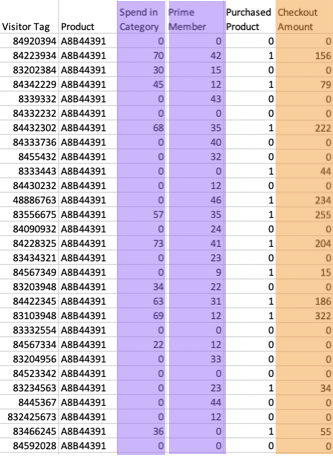

### Data Loading and Data Splitting

To understand the full potential of the principal components techniques we should consider more features to our regression model. To simplify the exposition however, we consider an example with only two regressor variables, the ```Spent in Category``` and the ```Prime Member``` variables. So here's grabbing the features from the dataset, and splitting again into training and test. 


In [2]:
data = pd.read_csv('../../data/review/MATH_Lecture_2_Data.csv')
print('Shape of the dataset:', data.shape)
data.head()


Shape of the dataset: (83, 6)


,Customer ID,Product Category,Spend in Category,Prime Member,Purchased Product,Checkout Amount
0,84920394,A8B44391,0.0,0,0,0.0
1,84223934,A8B44391,70.0,42,1,156.0
2,83202384,A8B44391,30.0,15,0,0.0
3,84342229,A8B44391,45.0,12,1,79.0
4,8339332,A8B44391,0.0,3,0,0.0


In [3]:
columns = ['Spend in Category', 'Prime Member', 'Purchased Product', 'Checkout Amount']

#features_columns = ['Spend in Category']
features_columns = ['Spend in Category', 'Prime Member']
#features_columns = ['Spend in Category', 'Prime Member', 'Purchased Product']
target_column = 'Checkout Amount'

features = data[features_columns].values
labels = data[target_column].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, labels, random_state = 0)

print('Shape of the training dataset:', X_train.shape)
print('Shape of the test dataset:', X_test.shape)

y_train, y_test = y_train.reshape(-1,1), y_test.reshape(-1,1)
print('Shape of the training and test labels:', y_train.shape, y_test.shape)
         

Shape of the training dataset: (62, 2)
Shape of the test dataset: (21, 2)
Shape of the training and test labels: (62, 1) (21, 1)


### Basic Data Visualization


#### 3D visualization, including the labels

Text(0.5, 0, 'Prime Member')

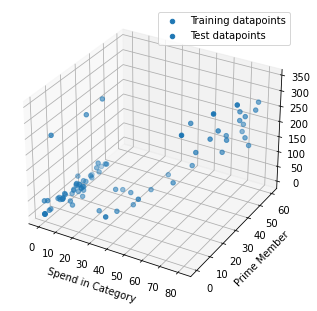

In [4]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
plt.clf
ax.scatter(X_train[:,0], X_train[:,1], y_train[:], '.', label = 'Training datapoints')
ax.scatter(X_test[:,0], X_test[:,1], y_test[:], '.', color = 'tab:blue', label = 'Test datapoints')
plt.axis('tight') 
plt.legend()
plt.xlabel(features_columns[0])
plt.ylabel(features_columns[1])


#### 2D visualization, only the features

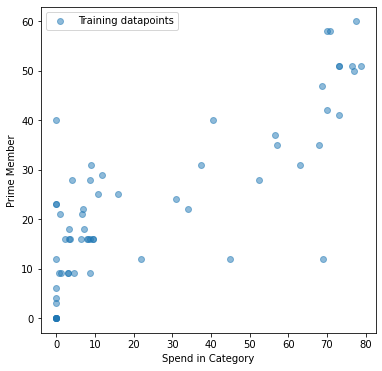

In [5]:
def plot_features_dataset():
    plt.scatter(X_train[:,0], X_train[:,1], label='Training datapoints', color ='tab:blue', alpha=.5)
    #plt.gca().set(aspect='equal')
    plt.xlabel(features_columns[0])
    plt.ylabel(features_columns[1])
    plt.legend()

plt.figure(figsize=(6, 6))
plot_features_dataset()
plt.show()

## <a name="2">PCR with Eigendecomposition (PCA) Step by Step</a> 
(<a href="#0">Go to top</a>)

Without going into [many details](https://arxiv.org/pdf/1404.1100.pdf), one way to find a basis that will change a dataset into a new dataset that is (1) invertible-friendly by eliminating multicollinearity and minimizing redundancy, and also (2) with a more interesting, less noisy, structure, is to find the so-called __principal components__ of the dataset. These principal components will form the desired change of basis $\mathbf{P}$. 

Specifically, to find the principal components we compute the eigenvectors of the covariance matrix ($\mathbf{X}^T \mathbf{X}$). Turns out such a choice diagonalizes the covariance matrix ($\mathbf{X}_{new}^T \mathbf{X}_{new}$), and so the new covariance matrix has an inverse, and the OLS works! This technique of extracting the principal components of a dataset is generally known as __Principal Component Analysis (PCA)__, and thus the regression on the dataset created with the help of the principal components is called __Principal Components Regression (PCR)__.

Let's see how to implement this, step by step. For a given dataset $\mathbf{X}$, here are the steps to implement PCR using the eigendecomposition of the covariance matrix to extract the principal components:
* <a href="#21"> PCA Step 1</a>: standardize the $\mathbf{X}$ features dataset (at least center the dataset by subtracting the mean)
* <a href="22">PCA Step 2</a>: compute the covariance matrix $\mathbf{X}^T \mathbf{X}$
* <a href="#23">PCA Step 3</a>: compute the eigenvectors of the covariance matrix
* <a href="#24">PCA Step 4</a>: sort the eigenvalues from largest to smallest, and define the change of basis $\mathbf{P}$ as the matrix whose columns are the corresponding sorted aigenvectors
* <a href="#25">PCA Step 5</a>: derive the new dataset $\mathbf{X}_{new} = \mathbf{X}$$\mathbf{P}$, performing the change of basis
* <a href="#26">PC Regression Step 6</a>: apply linear regression on the new dataset $\mathbf{X}_{new}$


> <a name="21">__PCA Step 1__: __Standardize the $\mathbf{X}$ features dataset__</a>. This is an important step, as PCA is a variance maximizing technique, looking for principal components by 'analyzing' and 'sorting' the covariances of the different features. Standardizing the dataset will set all features means to 0 and all their standard deviations to 1, so differentiating by covariances would be more accurate, unaffected by different feature scales. 


Uncentered features means: [25.02026971127524, 23.451612903225808]
Uncentered features standard deviations: [29.064679124540724, 16.407784756765604]
Centered features means: [8.953411488912552e-17, -7.879002110243047e-17]
Centered features standard deviations: [1.0, 0.9999999999999998]


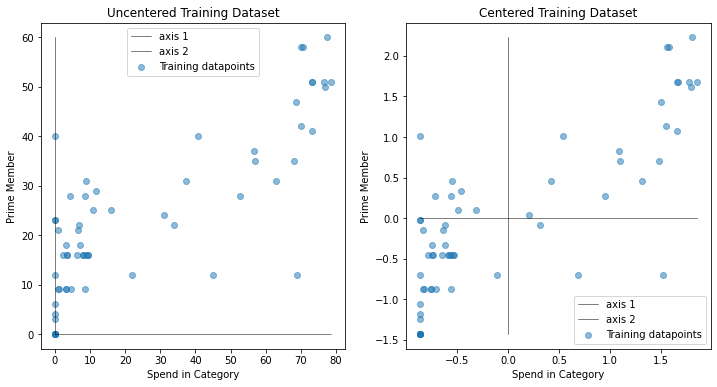

In [6]:
def plot_features_dataset():
    plt.scatter(X_train[:,0], X_train[:,1], label='Training datapoints', color ='tab:blue', alpha=.5)
    #plt.gca().set(aspect='equal')
    plt.plot([0, 0], [X_train[:,1].min(), X_train[:,1].max()], label="axis 1", linewidth=.5, color='black')
    plt.plot([X_train[:,0].min(), X_train[:,0].max()], [0, 0], label="axis 2", linewidth=.5, color='black')
    plt.xlabel(features_columns[0])
    plt.ylabel(features_columns[1])
    plt.legend()

plt.figure(figsize=(12, 6))

print('Uncentered features means:', [X_train[:,i].mean() for i in range(X_train.shape[1])])
print('Uncentered features standard deviations:', [X_train[:,i].std() for i in range(X_train.shape[1])])
plt.subplot(1,2,1)
plot_features_dataset()
plt.title("Uncentered Training Dataset")
plt.legend()

# Scale the dataset with custom standard scaler
def standardize_dataset(X_train, X_test):
    return (X_train - X_train.mean(axis = 0))/X_train.std(axis = 0), \
            (X_test - X_train.mean(axis = 0))/X_train.std(axis = 0), 
X_train, X_test = standardize_dataset(X_train, X_test)

print('Centered features means:', [X_train[:,i].mean() for i in range(X_train.shape[1])])
print('Centered features standard deviations:', [X_train[:,i].std() for i in range(X_train.shape[1])])
plt.subplot(1,2,2)
plot_features_dataset()
plt.title("Centered Training Dataset")
plt.legend()

plt.show()


Geometrically, subtracting the mean centers the features data around the origin of the coordinate system, as shown above. In this new setting, it's easier to analyze the spreads of features around their means with respect to each of the other features. Best way to quantify these so-called covariances, is to compute and examine the covariance matrix.


> <a name="22">__PCA Step 2__: __Compute the $\mathbf{X}^T \mathbf{X}$ covariance matrix__</a>. The covariance matrix is a square matrix giving the covariances between each pair of variables. On the diagonal of the covariance matrix we have variances (of each variable), and the other elements are the covariances (of any pair of two variables). Note that the covariance matrix is *symmetrical*, and its entries are *non-negative*. Here’s how to obtain the covariance matrix in Numpy.


In [7]:
# Covariance matrix from scratch - need to normalize
cov_matrix = (1.0/(X_train.shape[0]-1))*X_train.T.dot(X_train)
print('Custom covariance matrix: \n {} '.format(cov_matrix))

# Covariance matrix using numpy.cov() - normalized by default
cov_matrix = np.cov(X_train.T)
print('Numpy covariance matrix: \n {} '.format(cov_matrix))


Custom covariance matrix: 
 [[1.01639344 0.82237647]
 [0.82237647 1.01639344]] 
Numpy covariance matrix: 
 [[1.01639344 0.82237647]
 [0.82237647 1.01639344]] 


> <a name="23">__PCA Step 3__: __Eigendecomposition of the covariance matrix__</a>. Eigenvectors, eigenvalues and eigendecomposition are often one of the most useful notions we will encounter when studying linear algebra. For a symetrical and positive definite square matrix, such the $\mathbf{X}^T \mathbf{X}$ covariance matrix here,
* the eigenvectors are vectors which are stretched by the matrix without changing direction,
* the eigenvalues are the amount that the eigenvectors are stretched by the application of the matrix, and
* the eigendecomposition of the symmetric matrix is given by $\mathbf{E} \mathbf{D} \mathbf{E}^{-1}$, where the columns of $\mathbf{E}$ are the eigenvectors, and $\mathbf{D}$ is a diagonal matrix with values corresponding to the eigenvalues.

For more details on solving step by step for the eigenvalues and eigenvectors of a simple matrix check [this](http://d2l.ai/chapter_appendix-mathematics-for-deep-learning/eigendecomposition.html?highlight=decomposition#an-example). We can also perform the eigendecomposition through the built-in Numpy's ```np.linalg.eig```, that returns a tuple, where the first element represents the eigenvalues and the second one represents the eigenvectors.


In [8]:
# Find the eigenvectors and eigenvalues
values, vectors = np.linalg.eig(cov_matrix)#.reshape(-1,1))
print('Eigenvalues: \n', values)
print('Eigenvectors: \n', vectors)


Eigenvalues: 
 [1.83876991 0.19401697]
Eigenvectors: 
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


> <a name="24">__PCA Step 4__: __Change of basis__</a>. Intuitively, eigenvectors of the covariance matrix are particular new 'directions' in the dataset, characterized by their respective magnitudes, or importances, as reflected by their corresponding eigenvalues. Larger eigenvalues correspond to more important directions, with larger variances, believed to represent most interesting structures of the dataset (that *might* also better correlate with the target). We can thus quantify how 'principal' each direction is, by sorting the eigenvectors according to their corresponding eigenvalues. In which case, the lower eigenvalues and their corresponding eigenvectors would represent noise, and can be either assigned lower priority or *discarded all together* if noise reduction or dimensionality reduction is desired. 


In [9]:
# Sort by the largest eigenvalue
sortedValsVecs = sorted(zip(values, vectors.T), key=lambda x: x[0].real, reverse=True)
# NEEDED vectors.T to avoid reading the PCs in wrong order #            

sorted_values, sorted_vectors = [], []
for i, j in sortedValsVecs:
    sorted_values.append(i)
    sorted_vectors.append(j)
print('Sorted eigenvalues:\n', sorted_values)
print('Sorted eigenvectors:\n', sorted_vectors)
#print('Max Eigenvalue: \n', sorted_values[0])
#print('Principal Component 1: \n', sorted_vectors[0])


Sorted eigenvalues:
 [1.838769911605414, 0.19401697364048764]
Sorted eigenvectors:
 [array([0.70710678, 0.70710678]), array([-0.70710678,  0.70710678])]


Let's visualize the principal components as vectors over the training data, using the eigenvectors to define the direction of the vectors, and the eigenvalues to define the length of the vectors. 


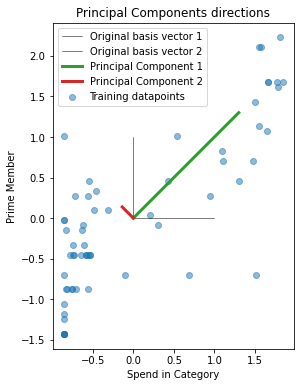

In [10]:
# Plot Principal Components (directions)
plt.figure(figsize=(6, 6))
plt.scatter(X_train[:,0], X_train[:,1], label='Training datapoints', color ='tab:blue', alpha=.5)
x0 = np.linspace(np.min(X_train[:,0]), np.max(X_train[:,0]), X_train[:,0].shape[0])

plt.plot([0, 1], [0, 0], label="Original basis vector 1", linewidth=.5, color='black')
plt.plot([0, 0], [0, 1], label="Original basis vector 2", linewidth=.5, color='black')

for i, (comp, var) in enumerate(zip(sorted_vectors, sorted_values)):
    #print(i, comp, var)
    comp = comp * var  # scale component by its variance explanation power
    plt.plot([0, comp[0]], [0, comp[1]], 
             label=f"Principal Component {i+1}", linewidth=3, color=f"C{i + 2}")

plt.gca().set(aspect='equal',
              title="Principal Components directions",
              xlabel=features_columns[0], ylabel=features_columns[1])

plt.legend()
plt.show()

Firstly, note that the eigenvectors are orthogonal, as accurately captured by the vizualization above (that is expected as the eigenvectors of symmetric matrices - like our covariance matrix here, are ortogonal). Secondly, also note that one of the eigenvectors goes closer through the middle of the datapoints cloud (like drawing a line of best
fit), while the other eigenvector  seems less important. The first eigenvector is the so-called first principal component which explains most of the variance in the dataset, and orthogonal to that is the second principal component, which explains most of the remaining variance. With more original features, this would be repeated for the number of principal components, which equals to the number of the original features. As a side note, because $\mathbf{E}$ is an orthonormal matrix, $\mathbf{E}^{-1}= \mathbf{E}^T$ and the eigendecomposition can also be written as $\mathbf{E} \mathbf{D} \mathbf{E}^T$. 

Moreover, what this means in practice, is that the first principal component is a *linear combination of the original variables* capturing the maximum variance in the dataset. The first principal component can equivalently be defined as a direction that maximizes the variance of the data projected on its direction. The second principal component is also a linear combination of original variables which captures the remaining variance in the data set and is uncorrelated with the first component, while the variance of the projected data is smaller. We can calculate the percentage of explained variance per principal component. 

In [11]:
explained_variances = []
for i in range(len(sorted_values)):
    explained_variances.append(sorted_values[i] / np.sum(sorted_values)) 

print('Explained variances per principal components:', explained_variances)
#print('The maximum explained variance:', np.max(explained_variances))
print('The sum of explained variances:', np.sum(explained_variances))

Explained variances per principal components: [0.9045561661929858, 0.09544383380701409]
The sum of explained variances: 0.9999999999999999


The first principal component accounts for most of the variance in the data, while the second principal component accounts for the remaining variance in the data, and the sum of explained variances is 1. Removing one (or more) of the smallest (less relevant) principal components, results in a lower dimensional transformation of the dataset, that accounts for the most variance in the dataset, presumably preserving the overall relationship between the data points. We show below selecting either a 2D or a 1D change of basis matrix, although dropping principal components (or dimensions) can be also implemented later if desired.


In [12]:
P = np.zeros((X_train.shape[1],X_train.shape[1]))
for i in range(len(sortedValsVecs)):
    P[:,i] = sortedValsVecs[i][1]
print('Change of basis matrix P (without dimensionality reduction): \n', P)

P = np.zeros((X_train.shape[1],X_train.shape[1]))
for i in range(len(sortedValsVecs)):
    P[:,i] = sortedValsVecs[i][1]
print('Change of basis matrix P: \n', P)


Change of basis matrix P (without dimensionality reduction): 
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Change of basis matrix P: 
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


__Note__: __PCA is mostly known and used as a dimensionality reduction technique__, or better said as an __unsupersived dimensionality reduction technique__. It worth pointing out, and repeating, that __PCA is a completely unsupervised__ dimensionality reduction technique, meaning that no information about targets is used in the process. Thus, PCA might result in lower dimensional datasets having a low predictive power on the target - for some datasets where the target is strongly correlated with directions that have low variance. For such cases, a supervised data transformation/dimensionality reduction like *Partial Least Square (PLS)* might be more succesful, as illustrated by [this sklearn example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html).


> <a name="25">__PCA Step 5__: __Data Transformation__</a>. Let's compute and vizualize the transformed dataset. Because our principal components are orthogonal to one another, the columns of the new dataset (the transformed variables) are linearly independent of one another - no more collinearity issues, linear regression should work! Before we even dive into regression on the new transformed dataset, let's display the two new variables of this dataset, i.e. the direction that explain the most variance in the data, and the second one.


In [13]:
# Transform the dataset using the Principal Components change of basis
X_train_PC, X_test_PC = X_train.dot(P), X_test.dot(P)


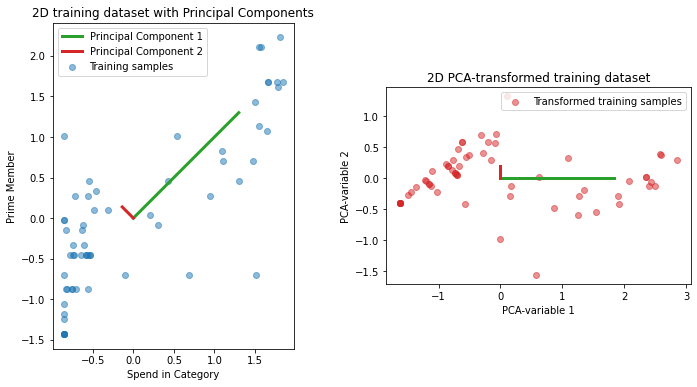

In [14]:
# Plot Principal Components directions
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(X_train[:,0], X_train[:,1], label = 'Training samples', color ='tab:blue', alpha=.5)
x0 = np.linspace(np.min(X_train[:,0]), np.max(X_train[:,0]), X_train[:,0].shape[0])

for i, (comp, var) in enumerate(zip(sorted_vectors, sorted_values)):
    #print(i, comp, var)
    comp = comp * var  # scale component by its variance explanation power
    plt.plot([0, comp[0]], [0, comp[1]], 
             label=f"Principal Component {i+1}", linewidth=3, color=f"C{i + 2}")

plt.gca().set(aspect='equal',
              title="2D training dataset with Principal Components",
              xlabel=features_columns[0], ylabel=features_columns[1])

plt.legend()

# Plot projected data onto the Principal Components
plt.subplot(1,2,2)
plt.scatter(X_train_PC[:,0], X_train_PC[:,1], label = 'Transformed training samples', color ='tab:red', alpha=.5)
x0 = np.linspace(np.min(X_train_PC[:,0]), np.max(X_train_PC[:,0]), X_train_PC[:,0].shape[0])

for i, (comp, var) in enumerate(zip(sorted_vectors, sorted_values)):
    #print(i, comp, var)
    comp = comp.dot(P)
    comp = comp * var  # scale component by its variance explanation power
    plt.plot([0, comp[0]], [0, comp[1]], linewidth=3, color=f"C{i + 2}")

plt.gca().set(aspect='equal',
              title="2D PCA-transformed training dataset",
              xlabel='PCA-variable 1', ylabel='PCA-variable 2')

plt.legend()
plt.show()

We can also examine the projection of the data onto the principal components, to conclude that indeed the first component captures more variance in the dataset than the second, for example.


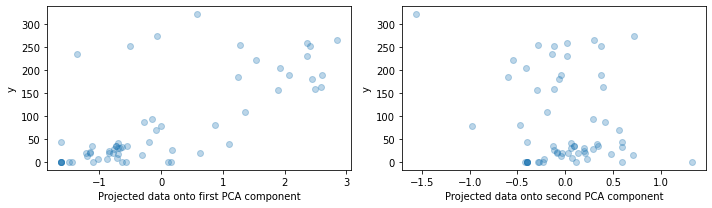

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].scatter(X_train.dot(sorted_vectors[0]), y_train, alpha=.3)
axes[0].set(xlabel='Projected data onto first PCA component', ylabel='y')
axes[1].scatter(X_train.dot(sorted_vectors[1]), y_train, alpha=.3)
axes[1].set(xlabel='Projected data onto second PCA component', ylabel='y')
plt.tight_layout()
plt.show()

> <a name="26">__PC Regression Step 6__: __Regression on the transformed training dataset__</a>. The transformed dataset (full dimensional or lower) is what the regressor of choice will use now as training data. Let's try both scenarios below - original dataset and PCA-transformed datase, and see which one produces a better model. 


In [16]:
# PC Regression 
scenarios = ['original dataset', '2D PCA-transformed dataset', '1D PC1-transformed dataset', '1D PC2-transformed dataset']
train_sets = [X_train, X_train_PC, X_train_PC[:,0].reshape(-1,1), X_train_PC[:,1].reshape(-1,1)]
test_sets = [X_test, X_test_PC, X_test_PC[:,0].reshape(-1,1), X_test_PC[:,1].reshape(-1,1)]

# OLS Regression solution
def OLS(X_train, y_train):
    X_a = np.concatenate((np.ones((X_train.shape[0],1)), X_train),axis=1)
    return np.linalg.inv(X_a.T.dot(X_a)).dot(X_a.T.dot(y_train)).reshape(-1,1)

# Regression Metrics - compare to sklearn implementation
#from sklearn.metrics import r2_score, mean_squared_error
def Regression_Metrics(y_true, y_predict):
    #print((y_true-y_predict).shape) # check shape #print((y_true-y_predict).shape) for broadcasting !!!
    MSE = np.mean((y_true-y_predict)**2)
    BMSE = np.mean((y_true-np.mean(y_true))**2)
    R2 = 1.0-(MSE/BMSE)         
    return MSE, np.sqrt(MSE), R2

for scenario, train, test in zip(scenarios, train_sets, test_sets):
    print('\n --- OLS on the', scenario)
    OLSmodel = OLS(train, y_train)
    print('Model parameters:', OLSmodel) 
    
    train_a = np.concatenate((np.ones((train.shape[0],1)), train),axis=1) # Augment dataset with a column of ones
    train_predictions = train_a.dot(OLSmodel)
    MSE, RMSE, R2 = Regression_Metrics(y_train, train_predictions)            
    print('R2 on training:', R2)    

    test_a = np.concatenate((np.ones((test.shape[0],1)), test),axis=1) # Augment dataset with a column of ones
    test_predictions = test_a.dot(OLSmodel) 
    MSE, RMSE, R2 = Regression_Metrics(y_test, test_predictions)            
    print('R2 on test:', R2)    



 --- OLS on the original dataset
Model parameters: [[83.84937559]
 [63.68571292]
 [ 8.34827582]]
R2 on training: 0.558772056520021
R2 on test: 0.7454885757802243

 --- OLS on the 2D PCA-transformed dataset
Model parameters: [[ 83.84937559]
 [ 50.93572191]
 [-39.12947702]]
R2 on training: 0.558772056520021
R2 on test: 0.7454885757802241

 --- OLS on the 1D PC1-transformed dataset
Model parameters: [[83.84937559]
 [50.93572191]]
R2 on training: 0.5260172187078561
R2 on test: 0.6158545629952481

 --- OLS on the 1D PC2-transformed dataset
Model parameters: [[ 83.84937559]
 [-39.12947702]]
R2 on training: 0.03275483781216515
R2 on test: 0.17112576380383282


## <a name="3">PCR with Eigendecomposition (PCA) Summary</a> 
(<a href="#0">Go to top</a>)

In [17]:
# PCA Step 1_: Standardize the features dataset (custom standard scaler here)
def standardize_dataset(X_train, X_test):
    return (X_train - X_train.mean(axis = 0))/X_train.std(axis = 0), \
            (X_test - X_train.mean(axis = 0))/X_train.std(axis = 0)
X_train, X_test = standardize_dataset(X_train, X_test)

# PCA Step 2: Compute the covariance matrix (custom code here)
cov_matrix = (1.0/(X_train.shape[0]-1))*X_train.T.dot(X_train)

# PCA Step 3: Eigendecomposition of the covariance matrix (find the eigenvectors and eigenvalues)
values, vectors = np.linalg.eig(cov_matrix)#.reshape(-1,1))

# PCA Step 4: Change of basis
# Sort by the largest eigenvalue
sortedValsVecs = sorted(zip(values, vectors.T), key=lambda x: x[0].real, reverse=True)
sorted_values, sorted_vectors = [], []
for i, j in sortedValsVecs:
    sorted_values.append(i)
    sorted_vectors.append(j)
# Change of basis   
P = np.zeros((X_train.shape[1],X_train.shape[1]))
for i in range(len(sortedValsVecs)):
    P[:,i] = sortedValsVecs[i][1]

# PCA Step 5: Data Transformation (using the Principal Components change of basis)
X_train_PC, X_test_PC = X_train.dot(P), X_test.dot(P)
    
# PC Regression 
scenarios = ['original dataset', '2D PCA-transformed dataset', '1D PC1-transformed dataset', '1D PC2-transformed dataset']
train_sets = [X_train, X_train_PC, X_train_PC[:,0].reshape(-1,1), X_train_PC[:,1].reshape(-1,1)]
test_sets = [X_test, X_test_PC, X_test_PC[:,0].reshape(-1,1), X_test_PC[:,1].reshape(-1,1)]

# OLS Regression
def OLS(X_train, y_train):
    X_a = np.concatenate((np.ones((X_train.shape[0],1)), X_train),axis=1)
    return np.linalg.inv(X_a.T.dot(X_a)).dot(X_a.T.dot(y_train)).reshape(-1,1)

# Regression Metrics - compare to sklearn implementation
#from sklearn.metrics import r2_score, mean_squared_error
def Regression_Metrics(y_true, y_predict):
    #print((y_true-y_predict).shape) # check shape #print((y_true-y_predict).shape) for broadcasting !!!
    MSE = np.mean((y_true-y_predict)**2)
    BMSE = np.mean((y_true-np.mean(y_true))**2)
    R2 = 1.0-(MSE/BMSE)         
    return MSE, np.sqrt(MSE), R2

for scenario, train, test in zip(scenarios, train_sets, test_sets):
    print('\n --- OLS on the', scenario)
    OLSmodel = OLS(train, y_train)
    print('Model parameters:', OLSmodel) 
    
    train_a = np.concatenate((np.ones((train.shape[0],1)), train),axis=1) # Augment dataset with a column of ones
    train_predictions = train_a.dot(OLSmodel)
    MSE, RMSE, R2 = Regression_Metrics(y_train, train_predictions)            
    print('R2 on training:', R2)    

    test_a = np.concatenate((np.ones((test.shape[0],1)), test),axis=1) # Augment dataset with a column of ones
    test_predictions = test_a.dot(OLSmodel) 
    MSE, RMSE, R2 = Regression_Metrics(y_test, test_predictions)            
    print('R2 on test:', R2)    



 --- OLS on the original dataset
Model parameters: [[83.84937559]
 [63.68571292]
 [ 8.34827582]]
R2 on training: 0.558772056520021
R2 on test: 0.7454885757802241

 --- OLS on the 2D PCA-transformed dataset
Model parameters: [[ 83.84937559]
 [ 50.93572191]
 [-39.12947702]]
R2 on training: 0.558772056520021
R2 on test: 0.7454885757802241

 --- OLS on the 1D PC1-transformed dataset
Model parameters: [[83.84937559]
 [50.93572191]]
R2 on training: 0.526017218707856
R2 on test: 0.6158545629952481

 --- OLS on the 1D PC2-transformed dataset
Model parameters: [[ 83.84937559]
 [-39.12947702]]
R2 on training: 0.03275483781216493
R2 on test: 0.17112576380383238


## <a name="4">PCR with Eigendecomposition (PCA) sklearn Implementation</a> 
(<a href="#0">Go to top</a>)

The ordering of the eigenvalues (and their corresrponding eigenvectors) from highest to lowest is implemented by default with sklearn's ```PCA()```.

In [18]:
# PCA Step
# double check with PCA implementation in sklearn, already sorted eigenvalues/eigenvectors!
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train)
#print('sklearn PCA eigenvalues: \n', pca.explained_variance_)
#print('sklearn PCA eigenvectors: \n', pca.components_)
#print('sklearn PCA max eigenvalue: \n', pca.explained_variance_[0])
#print('sklearn PCA eigenvector with the max eigenvalue: \n', pca.components_[0])

#P = pca.components_.T
#print('sklearn PCA change of basis matrix P: \n', P)

X_train_PC, X_test_PC = pca.transform(X_train), pca.transform(X_test)
#print('2nd training datapoint:\n', X_train[1])
#print('New 2nd training datapoint:\n', X_train_PC[1])
#print("---------------------")  

# PC Regression Step
scenarios = ['original dataset', '2D PCA transformed dataset', '1D PC1-transformed dataset', '1D PC2-transformed dataset']
train_sets = [X_train, X_train_PC, X_train_PC[:,0].reshape(-1,1), X_train_PC[:,1].reshape(-1,1)]
test_sets = [X_test, X_test_PC, X_test_PC[:,0].reshape(-1,1), X_test_PC[:,1].reshape(-1,1)]

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

for scenario, train, test in zip(scenarios, train_sets, test_sets):
    OLSmodel = LinearRegression()
    OLSmodel.fit(train, y_train)
    print('\n --- OLS on the', scenario)
    print('Model parameters:', OLSmodel.intercept_, OLSmodel.coef_) 
    print('R2 on training:', r2_score(y_train, OLSmodel.predict(train)))
    print('R2 on test:', r2_score(y_test, OLSmodel.predict(test)))
      


 --- OLS on the original dataset
Model parameters: [83.84937559] [[63.68571292  8.34827582]]
R2 on training: 0.558772056520021
R2 on test: 0.7454885757802242

 --- OLS on the 2D PCA transformed dataset
Model parameters: [83.84937559] [[50.93572191 39.12947702]]
R2 on training: 0.558772056520021
R2 on test: 0.7454885757802242

 --- OLS on the 1D PC1-transformed dataset
Model parameters: [83.84937559] [[50.93572191]]
R2 on training: 0.526017218707856
R2 on test: 0.6158545629952481

 --- OLS on the 1D PC2-transformed dataset
Model parameters: [83.84937559] [[39.12947702]]
R2 on training: 0.03275483781216504
R2 on test: 0.17112576380383326


## <a name="4">PCR with Singular Value Decomposition (SVD)</a> 
(<a href="#0">Go to top</a>)

Again without going into [many details](https://arxiv.org/pdf/1404.1100.pdf), the principal components transformation can be achieved with another matrix factorization, the __Singular Value Decomposition (SVD)__ of the features matrix $\mathbf{X}$ (up to a dimensional scalar). Turns out such a choice also addresses the regression issues - diagonalizes the covariance matrix of the transformed data, and so the new covariance matrix has an inverse, and the OLS works! 

#### What is SVD?

The eigenvalues and eigenvectors are defined only for squared matrices. The Singular Value Decomposition (SVD) is a matrix factorization that generalizes the eigendecomposition of a square normal matrix to __any rectangular matrix__. For any $n\times m$ matrix $\mathbf{X}$, the following decomposition always exists:

$$\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T, $$

where $\mathbf{U}$ is a column-orthonormal $n\times r$ matrix, $r$ is the rank of the matrix $\mathbf{X}$ (number of linearly independent rows or columns), $\mathbf{\Sigma}$ is a diagonal $r\times r$ matrix where the elements are sorted in descending order, and $\mathbf{V}$ is a column-orthonormal $r\times m$ matrix. 

The diagonal entries, known as the __singular values__ of $\mathbf{X}$, are the square roots of the eigenvalues of ($\mathbf{X} \mathbf{X}^{T}$) and ($\mathbf{X}^{T} \mathbf{X}$). The number of non-zero singular values is equal to the rank of $\mathbf{X}$. The columns of $\mathbf{U}$ and the columns of $\mathbf{V}$, called the __left-singular vectors__ and __right-singular vectors__ of $\mathbf{X}$, respectively, are the eigenvectors of ($\mathbf{X} \mathbf{X}^{T}$) and ($\mathbf{X}^{T} \mathbf{X}$), respectively. Numpy's ```np.linalg.svd()``` is a good algorithm to obtain the SVD of a matrix, returning all three components.

In summary, for a given dataset $\mathbf{X}$, here are the steps to implement SVD of the original data matrix to extract the change of basis and transform the dataset:
* standardize the $\mathbf{X}$ features dataset (at least center the dataset by subtracting the mean)
* compute the SVD of the $\frac{1}{\sqrt{n-1}}\mathbf{X}$ matrix, and use the right-singular vectors to define the change of basis $\mathbf{P}$
* derive the new dataset $\mathbf{X}_{new} = \mathbf{X}$$\mathbf{P}$, performing the change of basis
* apply linear regression on the new dataset $\mathbf{X}_{new}$


In [19]:
# SVD Step 1_: Standardize the features dataset (custom standard scaler here)
# commented out here as we have already performed this step
# X_train, X_test = standardize_dataset(X_train, X_test)

# SVD Step 2: Compute the svd of the matrix Y, and use the right-singular vectors to define the change of basis

# Calculate the Y matrix
Y = X_train/np.sqrt(X_train.shape[0]-1)

# Compute the svd of the matrix Y
U, S, V = np.linalg.svd(Y, full_matrices=False)

# Use the right-singular vectors to define the change of basis
P = V.T
#print('P', P)

# SVD Step 3: Data Transformation (using the change of basis)
X_train_SVD, X_test_SVD = X_train.dot(P), X_test.dot(P)
    
# PC Regression Step 4
scenarios = ['original dataset', '2D SVD-transformed dataset', '1D PC1-transformed dataset', '1D PC2-transformed dataset']
train_sets = [X_train, X_train_SVD, X_train_SVD[:,0].reshape(-1,1), X_train_SVD[:,1].reshape(-1,1)]
test_sets = [X_test, X_test_SVD, X_test_SVD[:,0].reshape(-1,1), X_test_SVD[:,1].reshape(-1,1)]

# OLS Regression
def OLS(X_train, y_train):
    X_a = np.concatenate((np.ones((X_train.shape[0],1)), X_train),axis=1)
    return np.linalg.inv(X_a.T.dot(X_a)).dot(X_a.T.dot(y_train)).reshape(-1,1)

for scenario, train, test in zip(scenarios, train_sets, test_sets):
    print('\n --- OLS on the', scenario)
    OLSmodel = OLS(train, y_train)
    print('Model parameters:', OLSmodel) 
    
    train_a = np.concatenate((np.ones((train.shape[0],1)), train),axis=1) # Augment dataset with a column of ones
    train_predictions = train_a.dot(OLSmodel)
    MSE, RMSE, R2 = Regression_Metrics(y_train, train_predictions)            
    print('R2 on training:', R2)    

    test_a = np.concatenate((np.ones((test.shape[0],1)), test),axis=1) # Augment dataset with a column of ones
    test_predictions = test_a.dot(OLSmodel) 
    MSE, RMSE, R2 = Regression_Metrics(y_test, test_predictions)            
    print('R2 on test:', R2)    



 --- OLS on the original dataset
Model parameters: [[83.84937559]
 [63.68571292]
 [ 8.34827582]]
R2 on training: 0.558772056520021
R2 on test: 0.7454885757802241

 --- OLS on the 2D SVD-transformed dataset
Model parameters: [[83.84937559]
 [50.93572191]
 [39.12947702]]
R2 on training: 0.5587720565200212
R2 on test: 0.7454885757802239

 --- OLS on the 1D PC1-transformed dataset
Model parameters: [[83.84937559]
 [50.93572191]]
R2 on training: 0.526017218707856
R2 on test: 0.6158545629952481

 --- OLS on the 1D PC2-transformed dataset
Model parameters: [[83.84937559]
 [39.12947702]]
R2 on training: 0.032754837812164705
R2 on test: 0.17112576380383226


As a final note, we see that the change of basis by SVD of the data matrix is same as the one we obtained leveraging the eigendecomposition of the covariance matrix of the data matrix. Both PCA and SVD are fundamentally dimensionality reduction algorithms, but can also be useful as tools for visualization, for noise filtering, and for feature extraction and engineering.

To summarize, PCR is a regressor composed of two steps: first, PCA is applied to the training data, possibly performing dimensionality reduction; then, a regressor is trained on the transformed samples. While PCR specifically points to a linear regressor, a KNN regressor or any other regressor can also be used for the second step!

## <a name="100">Summary</a> 
(<a href="#0">Go to top</a>)

* Matrix multiplication can be geometrically interpreted as uniform distortions of the underlying coordinates. They represent a very restricted, but mathematically clean, way to transform vectors.
* Principal Components Analysis is the process of computing the principal components of a dataset and using them to perform a change of basis on the data (streamlining machine learning solutions), sometimes using only the first few principal components and ignoring the rest (performing dimensionality reduction).
* Principal components are often computed by eigendecomposition of the data covariance matrix or singular value decomposition of the data matrix. 
* Principal Components Analysis can be used for dimensionality reduction alone for any machine learning problems, not just regression. 
* Principal Components Analysis for dimensionality reduction also transforms a high dimensional data to low dimensional data so that it can be visualized easily.



# End of Notebook

![MLU Logo](https://drive.corp.amazon.com/view/bwernes@/MLU_Logo.png?download=true)